# Movie Recommnedation System

Data retrieved from: https://www.kaggle.com/datasets/ggtejas/tmdb-imdb-merged-movies-dataset

Have you ever watched a movie, and felt yourself longing for a taste of what it gave you, only to never find it? Maybe it's the cinematic spectacle of a Nolan film, or the laughs and giggles of a Hangover movie, at the end of the day each movie has it's own "profile", and the purpose of this notebook is to find these profiles for each movie, and use them to build a recommendation system.

For this task, from my own foundational knowledge, I've identified 5 characteristics that define each movie and uniquely identify their profile: cast, director(s), keywords used in association with the movie, genre, and production company.

In [38]:
#imports
import pandas as pd
from scipy.sparse import save_npz
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import os
from google.colab import userdata, files
import kagglehub

In [30]:
#pull dataset
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
path = kagglehub.dataset_download("ggtejas/tmdb-imdb-merged-movies-dataset")

df = pd.read_csv(path + "/TMDB  IMDB Movies Dataset.csv")

Using Colab cache for faster access to the 'tmdb-imdb-merged-movies-dataset' dataset.


# Data Exploration

In [28]:
#get columns
print(df.columns)

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'tconst', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords', 'directors', 'writers', 'averageRating', 'numVotes',
       'cast'],
      dtype='object')


In [12]:
#describe data

df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.353610e+05,435361.000000,435361.000000,4.353610e+05,435361.000000,4.353610e+05,435361.000000,435361.000000,4.353610e+05
mean,4.909549e+05,3.606441,48.951663,1.653350e+06,66.469025,6.495439e+05,2.198243,6.235379,3.073923e+03
std,3.604561e+05,3.148480,513.213038,2.618658e+07,63.633343,7.418160e+06,11.352884,1.308649,3.375093e+04
min,2.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,5.000000e+00
25%,2.094140e+05,0.000000,0.000000,0.000000e+00,15.000000,0.000000e+00,0.600000,5.500000,2.300000e+01
50%,4.180950e+05,4.600000,1.000000,0.000000e+00,80.000000,0.000000e+00,0.857000,6.300000,6.900000e+01
75%,7.073630e+05,6.200000,6.000000,0.000000e+00,96.000000,0.000000e+00,1.661000,7.100000,3.120000e+02
max,1.628053e+06,10.000000,34495.000000,2.923706e+09,14400.000000,8.880000e+08,2994.357000,10.000000,3.152370e+06


This immediately raises some alarms. For the fields "vote_count" and "num_votes", there is a significant difference between the maximum value and 75th percentile. We should investigate the frequency of these votes.

## Using TMDB data (vote_counts)

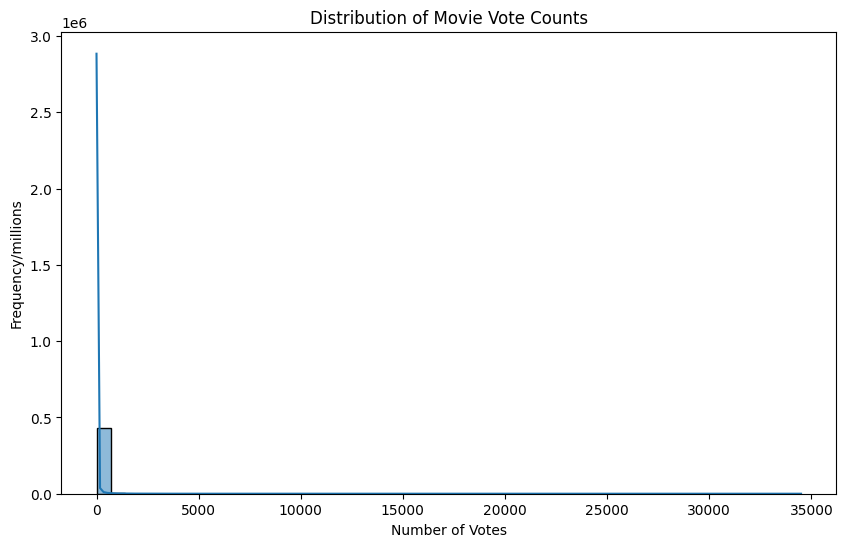

In [11]:
#plot distribution of movie by vote_counts
plt.figure(figsize=(10, 6))
sns.histplot(df['vote_count'], bins=50, kde=True)
plt.title('Distribution of Movie Vote Counts')
plt.xlabel('Number of Votes')
plt.ylabel('Frequency/millions')
plt.show()

This shows a massive disparity in the number of votes per movie, let's take a closer look

In [13]:
max_vote_count = df['vote_count'].max()
bins = np.arange(0, max_vote_count + 1000, 1000)
vote_count_bins = pd.cut(df['vote_count'], bins=bins, right=False)
vote_count_frequencies = vote_count_bins.value_counts().sort_index()
vote_count_frequencies_df = vote_count_frequencies.reset_index()
vote_count_frequencies_df.columns = ['Vote Count Range', 'Number of Movies']

print("Frequency distribution of movie vote counts:")
print(vote_count_frequencies_df)

Frequency distribution of movie vote counts:
   Vote Count Range  Number of Movies
0         [0, 1000)            431422
1      [1000, 2000)              1770
2      [2000, 3000)               667
3      [3000, 4000)               430
4      [4000, 5000)               234
5      [5000, 6000)               196
6      [6000, 7000)               142
7      [7000, 8000)                97
8      [8000, 9000)                63
9     [9000, 10000)                69
10   [10000, 11000)                43
11   [11000, 12000)                38
12   [12000, 13000)                34
13   [13000, 14000)                22
14   [14000, 15000)                27
15   [15000, 16000)                16
16   [16000, 17000)                15
17   [17000, 18000)                13
18   [18000, 19000)                13
19   [19000, 20000)                10
20   [20000, 21000)                12
21   [21000, 22000)                 5
22   [22000, 23000)                 3
23   [23000, 24000)                 5
24   

From this, we can see that an overwhelming majority of the movies have few votes, indicating low user engagement with these movies. We need to further investigate these movies

## Investigating IMDB Data (numVotes)

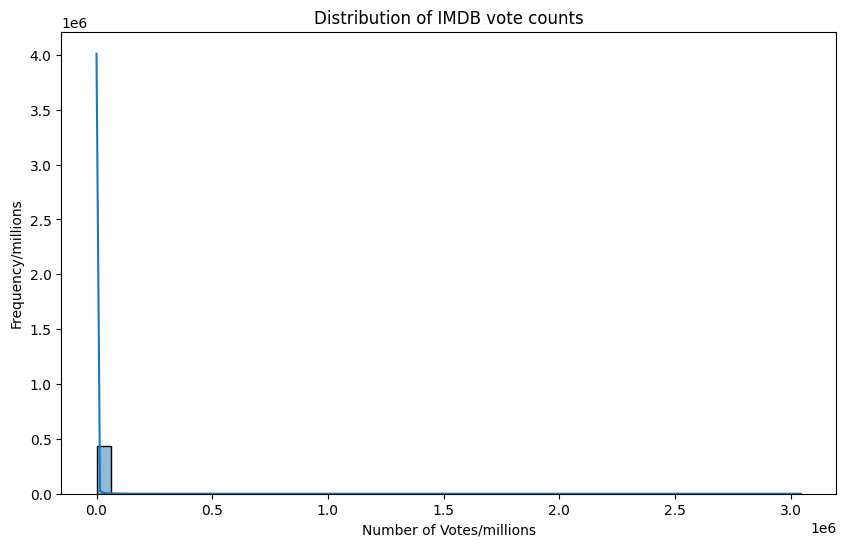

In [35]:
#plot distribution of movie
plt.figure(figsize=(10, 6))
sns.histplot(df['numVotes'], bins=50, kde=True)
plt.title('Distribution of IMDB vote counts')
plt.xlabel('Number of Votes/millions')
plt.ylabel('Frequency/millions')
plt.show()

Again, an overwhelming amount of movies fall close to 0 in terms of number of votes. Let's look back at the table.

In [41]:
max_vote_count = df['numVotes'].max()
bins = np.arange(0, max_vote_count + 100000, 100000)
vote_count_bins = pd.cut(df['numVotes'], bins=bins, right=False)
vote_count_frequencies = vote_count_bins.value_counts().sort_index()
vote_count_frequencies_df = vote_count_frequencies.reset_index()
vote_count_frequencies_df.columns = ['UMDB Vote Range', 'Number of Movies']

print("Frequency distribution of movie vote counts on IMDB:")
print(vote_count_frequencies_df)

Frequency distribution of movie vote counts on IMDB:
       UMDB Vote Range  Number of Movies
0          [0, 100000)            431806
1     [100000, 200000)              1323
2     [200000, 300000)               546
3     [300000, 400000)               251
4     [400000, 500000)               151
5     [500000, 600000)                96
6     [600000, 700000)                62
7     [700000, 800000)                58
8     [800000, 900000)                36
9    [900000, 1000000)                28
10  [1000000, 1100000)                 9
11  [1100000, 1200000)                18
12  [1200000, 1300000)                11
13  [1300000, 1400000)                 7
14  [1400000, 1500000)                 8
15  [1500000, 1600000)                 6
16  [1600000, 1700000)                 5
17  [1700000, 1800000)                 2
18  [1800000, 1900000)                 1
19  [1900000, 2000000)                 2
20  [2000000, 2100000)                 1
21  [2100000, 2200000)                 3
22  

## Comparing IMDB and TMDB data

Given the large amounts of low engagement movies by both IMDB and TMDB metrics, let's investigate the overlap in these movies

In [21]:
low_engagement = df[(df['vote_count'] < 1000) & (df['numVotes'] < 100000)]
print("Low Engagement Movies: " + str(len(low_engagement)))

high_engagement = df[~((df['vote_count'] < 1000) & (df['numVotes'] < 100000))]
print("High Engagement Movies: " + str(len(high_engagement)))

Low Engagement Movies: 431184
High Engagement Movies: 4177


This shows a nearly 100% overlap between the movies that are low-engagement on each platform, indicating that it isn't platform specific but rather these movies are generally not that popular among audiences.

This is alarming, but what we are concerned about in this system is not popularity of movies, but the similarity in quality and characteristics. This raises the question, are the movies lower in engagement also lower in depth of description and characteristics? In order to implement this system, we need adequate data to describe each movie. We'll investigate the frequency of null fields in each dataset for the target fields for movie characterization ie. genres, keywords, directors and cast.

In [22]:
features = ['genres', 'keywords', 'directors', 'cast']
comparison = pd.DataFrame({
    'Low Engagement Nulls': low_engagement[features].isnull().sum(),
    'High Engagement Nulls': high_engagement[features].isnull().sum()
})

print(f"Comparison of Nulls:")
print(comparison)

Comparison of Nulls:
           Low Engagement Nulls  High Engagement Nulls
genres                    79054                     66
keywords                 264679                    132
directors                  9940                      0
cast                      68540                     80


As we can see, the lower engagement movies hold a staggeringly larger share of the null values in the dataset, which would deem them irrelevant and more of a hindrance to our system.

While we can simply drop the null values and proceed as planned with the remaining data, the large share of null values in the lower engagement movies gives us insight into their nature: They are poorly described. Working with these lesser-described movies with lackluster information will only slow down the system.

As such, we will exclude the low engagement movies from our further operations on the dataset.

In [25]:
high_engagement.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.177000e+03,4177.000000,4177.000000,4.177000e+03,4177.000000,4.177000e+03,4177.000000,4177.000000,4.177000e+03
mean,2.017495e+05,6.556247,3517.987790,1.358156e+08,110.834091,4.102099e+07,33.109700,6.761575,2.184103e+05
std,3.001989e+05,1.504311,3852.870159,2.192310e+08,48.472244,5.131486e+07,84.240118,0.943013,2.642018e+05
min,5.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.800000,5.400000e+02
25%,8.068000e+03,6.220000,1325.000000,1.180000e+07,96.000000,5.000000e+06,16.459000,6.200000,8.065500e+04
50%,3.782100e+04,6.779000,2082.000000,6.176819e+07,107.000000,2.300000e+07,22.448000,6.800000,1.341750e+05
75%,3.387660e+05,7.345000,4087.000000,1.636922e+08,122.000000,5.700000e+07,33.311000,7.400000,2.461370e+05
max,1.619729e+06,10.000000,34495.000000,2.923706e+09,999.000000,4.600000e+08,2994.357000,9.300000,3.152370e+06


# Data Preparation

In [31]:
def prep_f(f):
  if pd.isnull(f):
    return []
  return [term.strip().lower().replace(" ","-") for term in f.split(",")]         #join multiple-word items with hyphens

def concat_row(row):
  return " ".join(row['genres']+ row['keywords']+row['directors']+row['cast'])    #convert rows data into one string



In [33]:

#clean dataset

df_cleaned=df[
    (df['vote_count'] >= 1000) &
    (df['numVotes'] >= 100000 )
].copy()

df_cleaned['release_date']=pd.to_datetime(df_cleaned['release_date'])
df_cleaned['release_year']=df_cleaned['release_date'].dt.year

features=['genres','keywords','directors','cast','production_companies']                               #select relevant columns
df_cleaned=df_cleaned[features + ['title']+['release_year']]

df_cleaned.dropna(inplace=True)                                                                        #drop null values, since null values impact recommendation system at this point


#create concat feature
for feature in features:
  df_cleaned[feature]=df_cleaned[feature].apply(prep_f)
df_cleaned['concat']=df_cleaned.apply(concat_row,axis=1)



In [35]:
tf=TfidfVectorizer(
    stop_words='english',
    token_pattern=r'(?u)[\w-]+')                                                #preserve hyphenated words
tf_matrix=tf.fit_transform(df_cleaned['concat'])                                 #create vector for each movie

In [41]:
#export movie titles
movies_export=df_cleaned[['title','release_year','concat']]
movies_export.to_csv("movies_db.csv", index=False)
save_npz("tf_matrix.npz", tf_matrix)


files.download("movies_db.csv")
files.download("tf_matrix.npz")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>